# Death Risk Prediction Using Classification Algorithms

**Disclaimer:** *The target variable (Total Deaths) in this notebook is calculated by summing deaths attributable to potentially overlapping risk factors. It is an artificial target used here purely to demonstrate classification pipelines and techniques. It should not be interpreted as a genuine epidemiological mortality risk measure.*

This notebook implements and compares multiple classification-based machine learning algorithms to predict the likelihood of death based on risk factors.

## Algorithms Implemented:
1. Logistic Regression
2. Support Vector Machine (SVM)
3. Decision Tree
4. Ensemble Modelling (Random Forest)

## 1. Import Libraries

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                           roc_auc_score, roc_curve, precision_recall_curve)
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

## 2. Load and Explore Data

In [98]:
# Load the dataset
df = pd.read_csv('Number of Deaths by Risk Factors.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst few rows:")
df.head()

Dataset Shape: (6840, 31)

Column Names:
['Entity', 'Code', 'Year', ' Outdoor air pollution ', 'High systolic blood pressure ', 'Diet high in sodium', ' Diet low in whole grains ', 'Alcohol use ', 'Diet low in fruits', 'Unsafe water source', 'Secondhand smoke', ' Low birth weight ', 'Child wasting  ', ' Unsafe sex ', 'Diet low in nuts and seeds ', ' Household air pollution from solid fuels', ' Diet low in vegetables ', 'Low physical activity', ' Smoking ', ' High fasting plasma glucose ', ' Air pollution ', ' High body-mass index ', ' Unsafe sanitation', ' No access to handwashing facility ', ' Drug use - Sex: Both - Age: All Ages (Number)', 'Low bone mineral density', ' Vitamin A deficiency', ' Child stunting ', 'Discontinued breastfeeding ', 'Non-exclusive breastfeeding', ' Iron deficiency']

First few rows:


,Entity,Code,Year,Outdoor air pollution,High systolic blood pressure,Diet high in sodium,Diet low in whole grains,Alcohol use,Diet low in fruits,Unsafe water source,...,High body-mass index,Unsafe sanitation,No access to handwashing facility,Drug use - Sex: Both - Age: All Ages (Number),Low bone mineral density,Vitamin A deficiency,Child stunting,Discontinued breastfeeding,Non-exclusive breastfeeding,Iron deficiency
0,Afghanistan,AFG,1990,3169,25633,1045,7077,356,3185,3702,...,9518,2798,4825,174,389,2016,7686,107,2216,564
1,Afghanistan,AFG,1991,3222,25872,1055,7149,364,3248,4309,...,9489,3254,5127,188,389,2056,7886,121,2501,611
2,Afghanistan,AFG,1992,3395,26309,1075,7297,376,3351,5356,...,9528,4042,5889,211,393,2100,8568,150,3053,700
3,Afghanistan,AFG,1993,3623,26961,1103,7499,389,3480,7152,...,9611,5392,7007,232,411,2316,9875,204,3726,773
4,Afghanistan,AFG,1994,3788,27658,1134,7698,399,3610,7192,...,9675,5418,7421,247,413,2665,11031,204,3833,812


In [99]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Data types
print("\nData Types:")
print(df.dtypes)

Missing Values:
Entity                                              0
Code                                              690
Year                                                0
 Outdoor air pollution                              0
High systolic blood pressure                        0
Diet high in sodium                                 0
 Diet low in whole grains                           0
Alcohol use                                         0
Diet low in fruits                                  0
Unsafe water source                                 0
Secondhand smoke                                    0
 Low birth weight                                   0
Child wasting                                       0
 Unsafe sex                                         0
Diet low in nuts and seeds                          0
 Household air pollution from solid fuels           0
 Diet low in vegetables                             0
Low physical activity                               0
 Smoking    

In [100]:
# Statistical summary
print("Statistical Summary:")
df.describe()

Statistical Summary:


,Year,Outdoor air pollution,High systolic blood pressure,Diet high in sodium,Diet low in whole grains,Alcohol use,Diet low in fruits,Unsafe water source,Secondhand smoke,Low birth weight,...,High body-mass index,Unsafe sanitation,No access to handwashing facility,Drug use - Sex: Both - Age: All Ages (Number),Low bone mineral density,Vitamin A deficiency,Child stunting,Discontinued breastfeeding,Non-exclusive breastfeeding,Iron deficiency
count,6840.000000,6.840000e+03,6.840000e+03,6.840000e+03,6.840000e+03,6.840000e+03,6.840000e+03,6.840000e+03,6.840000e+03,6.840000e+03,...,6.840000e+03,6.840000e+03,6.840000e+03,6840.000000,6840.000000,6840.000000,6840.000000,6840.000000,6840.000000,6840.000000
mean,2004.500000,8.458244e+04,2.242249e+05,4.049716e+04,3.869129e+04,5.484860e+04,2.395776e+04,4.408638e+04,3.036401e+04,5.912551e+04,...,8.986992e+04,3.152155e+04,2.179989e+04,10285.202047,8182.473246,2471.594444,11164.329678,431.456725,7171.853070,1421.363596
std,8.656074,3.511973e+05,8.634691e+05,1.752832e+05,1.479084e+05,2.112090e+05,9.451573e+04,2.020493e+05,1.222861e+05,2.502265e+05,...,3.450420e+05,1.463434e+05,9.668259e+04,39960.745145,32403.922936,12718.303403,52866.245579,1901.531732,31678.447189,6303.931822
min,1990.000000,0.000000e+00,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,...,2.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1997.000000,4.337500e+02,1.827750e+03,1.370000e+02,2.737500e+02,2.637500e+02,1.440000e+02,7.000000e+00,2.090000e+02,1.230000e+02,...,9.185000e+02,3.000000e+00,1.900000e+01,31.000000,43.000000,0.000000,1.000000,0.000000,3.000000,1.000000
50%,2004.500000,2.101000e+03,8.770500e+03,9.695000e+02,1.444000e+03,1.780500e+03,8.345000e+02,1.825000e+02,9.940000e+02,1.057000e+03,...,3.917000e+03,1.020000e+02,2.210000e+02,222.000000,277.000000,2.000000,41.500000,4.000000,60.500000,12.000000
75%,2012.000000,1.181025e+04,4.035550e+04,5.169750e+03,6.773250e+03,8.368000e+03,3.104750e+03,5.599250e+03,4.347750e+03,1.090325e+04,...,1.796775e+04,3.854000e+03,3.953500e+03,1224.250000,1232.000000,230.250000,1563.250000,71.250000,1315.500000,238.000000
max,2019.000000,4.506193e+06,1.084560e+07,1.885356e+06,1.844836e+06,2.441973e+06,1.046015e+06,2.450944e+06,1.304318e+06,3.033425e+06,...,5.019360e+06,1.842275e+06,1.200349e+06,494492.000000,437884.000000,207555.000000,833449.000000,33106.000000,505470.000000,73461.000000


## 3. Data Preprocessing

In [101]:
# Clean column names (remove leading/trailing spaces)
df.columns = df.columns.str.strip()

# Handle missing values - fill with median for numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Fill categorical columns with mode
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else 'Unknown')

print("Data after cleaning:")
print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")

Data after cleaning:
Shape: (6840, 31)
Missing values: 0


In [102]:
# Calculate total deaths per row (sum of all risk factors)
risk_factor_cols = [col for col in df.columns if col not in ['Entity', 'Code', 'Year']]
df['Total_Deaths'] = df[risk_factor_cols].sum(axis=1)

# Fix target leakage: We will predict the NEXT year's risk category based on THIS year's risk factors.
# Shift Total_Deaths by -1 within each Entity to get the target for the current year.
df = df.sort_values(['Entity', 'Year'])
df['Next_Year_Total_Deaths'] = df.groupby('Entity')['Total_Deaths'].shift(-1)

# Drop the last year for each country since we don't have next year's data for it
df = df.dropna(subset=['Next_Year_Total_Deaths']).copy()

# Create death risk categories based on NEXT year's total deaths
# Using percentiles computed on the full dataset to create balanced, consistent classes.
# "Low Risk": next year's death burden is in the lowest third of all observations.
# "Medium Risk": next year's death burden is in the middle third.
# "High Risk": next year's death burden is in the upper third.
percentiles = df['Next_Year_Total_Deaths'].quantile([0.33, 0.66]).values

def categorize_risk(deaths):
    if deaths <= percentiles[0]:
        return 'Low Risk'
    elif deaths <= percentiles[1]:
        return 'Medium Risk'
    else:
        return 'High Risk'

df['Death_Risk_Category'] = df['Next_Year_Total_Deaths'].apply(categorize_risk)

# Display distribution of categories
print("Death Risk Category Distribution:")
print(df['Death_Risk_Category'].value_counts())
print(f"\nPercentiles used: {percentiles}")

Death Risk Category Distribution:
Death_Risk_Category
High Risk      2248
Low Risk       2182
Medium Risk    2182
Name: count, dtype: int64

Percentiles used: [ 24926.89 172681.32]


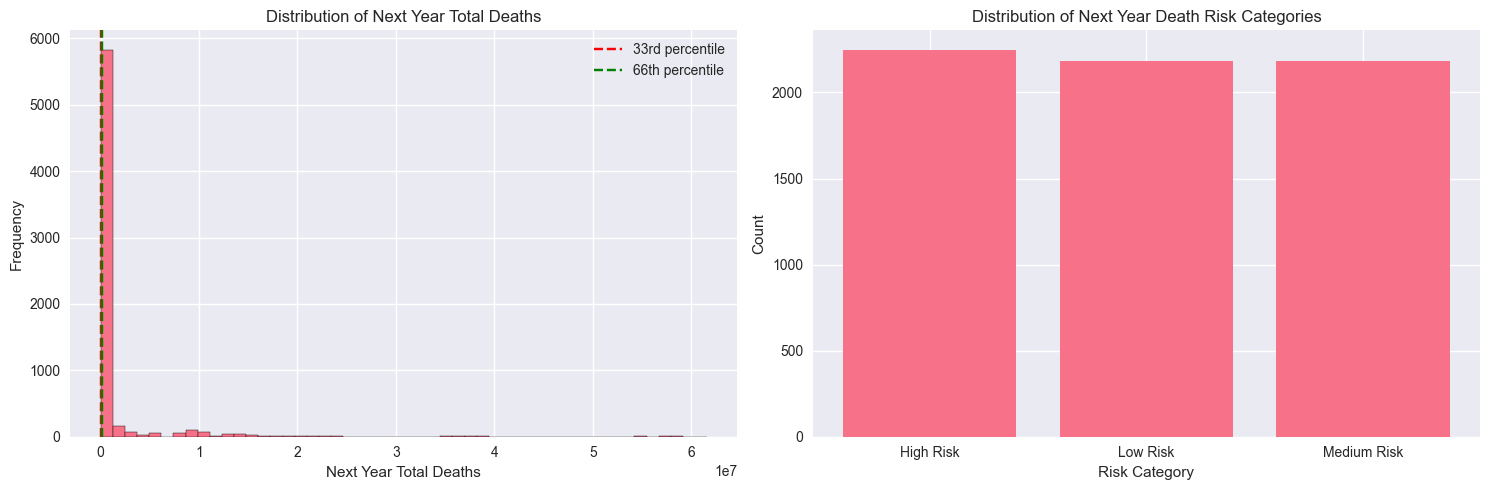

In [103]:
# Visualize the distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Target distribution
axes[0].hist(df['Next_Year_Total_Deaths'], bins=50, edgecolor='black')
axes[0].set_xlabel('Next Year Total Deaths')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Next Year Total Deaths')
axes[0].axvline(percentiles[0], color='r', linestyle='--', label='33rd percentile')
axes[0].axvline(percentiles[1], color='g', linestyle='--', label='66th percentile')
axes[0].legend()

# Risk category distribution
category_counts = df['Death_Risk_Category'].value_counts()
axes[1].bar(category_counts.index, category_counts.values)
axes[1].set_xlabel('Risk Category')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Next Year Death Risk Categories')

plt.tight_layout()
plt.show()

In [ ]:
# Encode target variable
le_target = LabelEncoder()
df['Target_Encoded'] = le_target.fit_transform(df['Death_Risk_Category'])

# Prepare features and target
# Exclude Entity and Code from features to force the model to generalize across geographical regions
feature_cols = risk_factor_cols
X = df[feature_cols]
y = df['Target_Encoded']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget classes: {le_target.classes_}")

Features shape: (6612, 31)
Target shape: (6612,)

Target classes: ['High Risk' 'Low Risk' 'Medium Risk']


In [ ]:
# Split the data chronologically to prevent time-series data leakage
# e.g., Train on past years (<= 2014), test on future years (> 2014)
train_df = df[df['Year'] <= 2014]
test_df = df[df['Year'] > 2014]

X_train = train_df[feature_cols]
y_train = train_df['Target_Encoded']
X_test = test_df[feature_cols]
y_test = test_df['Target_Encoded']

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining target distribution:")
print(y_train.value_counts())

Training set size: 5289
Test set size: 1323

Training target distribution:
Target_Encoded
0    1798
2    1746
1    1745
Name: count, dtype: int64


## 4. Feature Importance Analysis

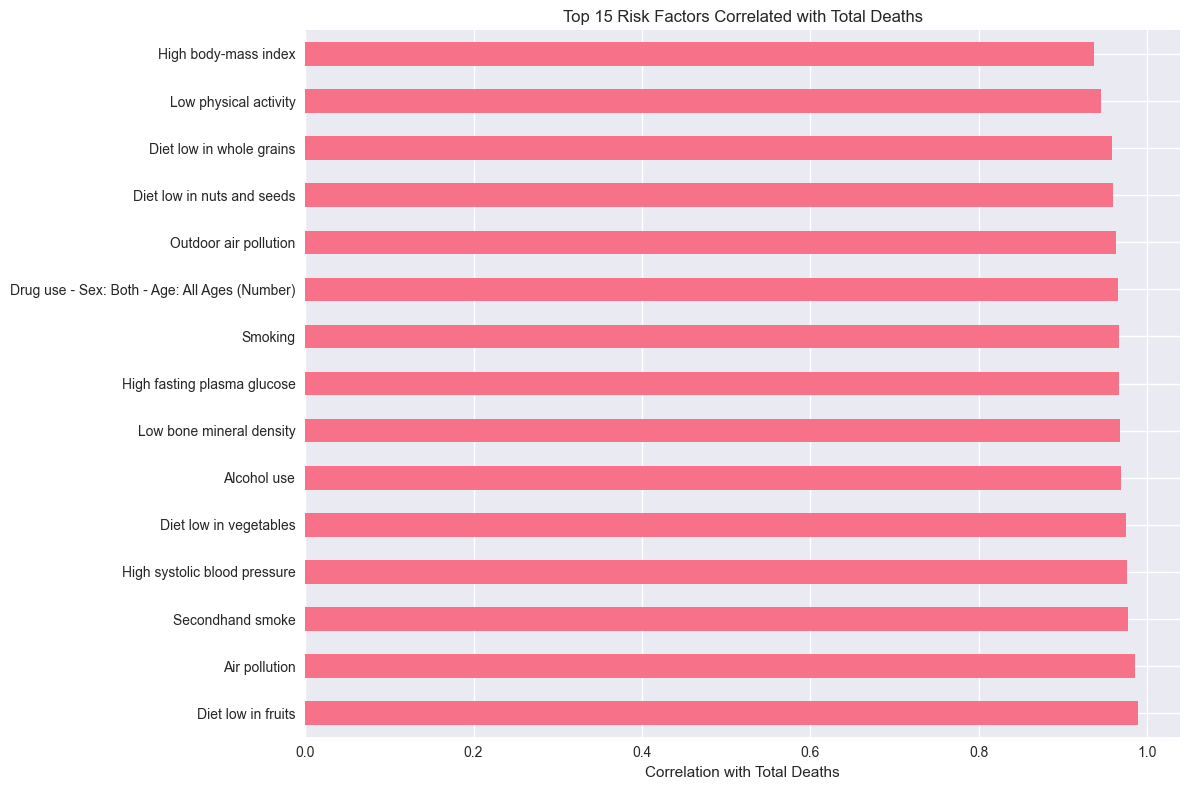

Top 10 Risk Factors by Correlation:
Total_Deaths                    1.000000
Diet low in fruits              0.989394
Air pollution                   0.985390
Secondhand smoke                0.977258
High systolic blood pressure    0.976219
Diet low in vegetables          0.974997
Alcohol use                     0.969224
Low bone mineral density        0.967397
High fasting plasma glucose     0.966784
Smoking                         0.966670
Name: Total_Deaths, dtype: float64


In [106]:
# Calculate correlation with target
correlations = df[risk_factor_cols + ['Total_Deaths']].corr()['Total_Deaths'].sort_values(ascending=False)

# Plot top correlations
plt.figure(figsize=(12, 8))
correlations.drop('Total_Deaths').head(15).plot(kind='barh')
plt.xlabel('Correlation with Total Deaths')
plt.title('Top 15 Risk Factors Correlated with Total Deaths')
plt.tight_layout()
plt.show()

print("Top 10 Risk Factors by Correlation:")
print(correlations.head(10))

### 5.1 Logistic Regression

In [109]:
# Multiclass Logistic Regression
print("="*50)
print("MULTICLASS LOGISTIC REGRESSION")
print("="*50)

mlr_model = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    random_state=42
 )
mlr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_mlr = mlr_model.predict(X_test_scaled)
y_pred_proba_mlr = mlr_model.predict_proba(X_test_scaled)

# Metrics
mlr_accuracy = accuracy_score(y_test, y_pred_mlr)
mlr_auc = roc_auc_score(y_test, y_pred_proba_mlr, multi_class='ovr')

print(f"Accuracy: {mlr_accuracy:.4f}")
print(f"ROC AUC (One-vs-Rest): {mlr_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_mlr, target_names=le_target.classes_))

MULTICLASS LOGISTIC REGRESSION
Accuracy: 0.9025
ROC AUC (One-vs-Rest): 0.9924

Classification Report:
              precision    recall  f1-score   support

   High Risk       0.98      0.96      0.97       450
    Low Risk       0.82      1.00      0.90       437
 Medium Risk       0.94      0.75      0.83       436

    accuracy                           0.90      1323
   macro avg       0.91      0.90      0.90      1323
weighted avg       0.91      0.90      0.90      1323



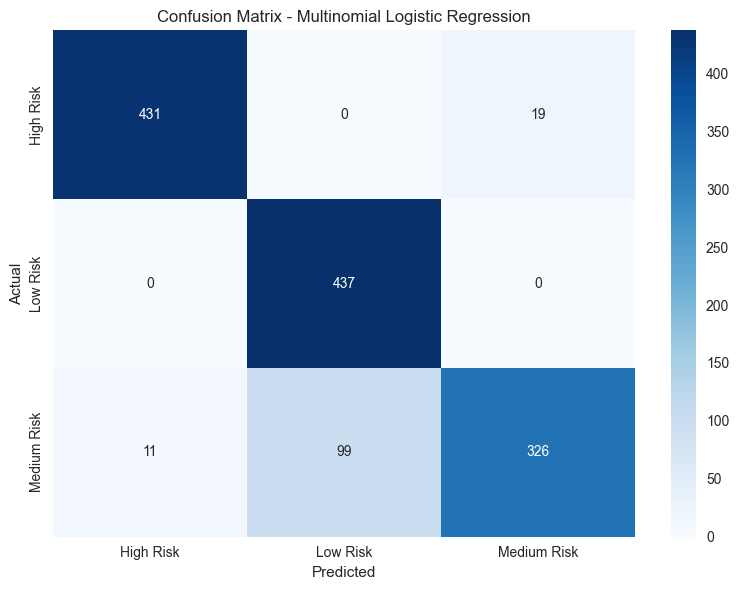

In [110]:
# Confusion Matrix
cm_mlr = confusion_matrix(y_test, y_pred_mlr)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_mlr, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Multinomial Logistic Regression')
plt.tight_layout()
plt.show()

### 5.3 Support Vector Machine (SVM)

In [111]:
# Support Vector Machine
print("="*50)
print("SUPPORT VECTOR MACHINE")
print("="*50)

# SVM with RBF kernel
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_svm = svm_model.predict(X_test_scaled)
y_pred_proba_svm = svm_model.predict_proba(X_test_scaled)

# Metrics
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_auc = roc_auc_score(y_test, y_pred_proba_svm, multi_class='ovr')

print(f"Accuracy: {svm_accuracy:.4f}")
print(f"ROC AUC (One-vs-Rest): {svm_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, target_names=le_target.classes_))

SUPPORT VECTOR MACHINE
Accuracy: 0.7098
ROC AUC (One-vs-Rest): 0.9000

Classification Report:
              precision    recall  f1-score   support

   High Risk       0.99      0.87      0.93       450
    Low Risk       0.60      0.80      0.69       437
 Medium Risk       0.58      0.45      0.51       436

    accuracy                           0.71      1323
   macro avg       0.72      0.71      0.71      1323
weighted avg       0.72      0.71      0.71      1323



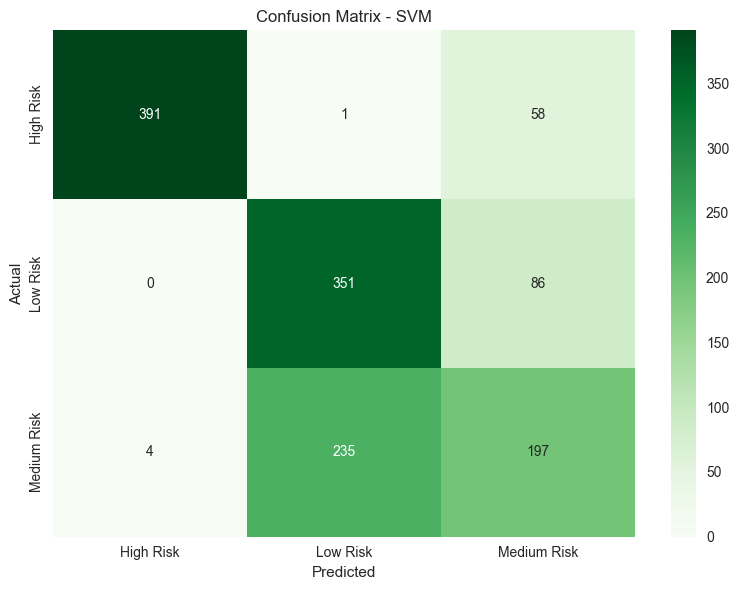

In [112]:
# Confusion Matrix for SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM')
plt.tight_layout()
plt.show()

### 5.4 Decision Tree

In [113]:
# Decision Tree
print("="*50)
print("DECISION TREE")
print("="*50)

dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_model.fit(X_train, y_train)  # Decision trees don't need scaling

# Predictions
y_pred_dt = dt_model.predict(X_test)
y_pred_proba_dt = dt_model.predict_proba(X_test)

# Metrics
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_auc = roc_auc_score(y_test, y_pred_proba_dt, multi_class='ovr')

print(f"Accuracy: {dt_accuracy:.4f}")
print(f"ROC AUC (One-vs-Rest): {dt_auc:.4f}")
print(f"Tree Depth: {dt_model.get_depth()}")
print(f"Number of Leaves: {dt_model.get_n_leaves()}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=le_target.classes_))

DECISION TREE
Accuracy: 0.9864
ROC AUC (One-vs-Rest): 0.9902
Tree Depth: 10
Number of Leaves: 65

Classification Report:
              precision    recall  f1-score   support

   High Risk       0.98      0.99      0.99       450
    Low Risk       0.99      0.99      0.99       437
 Medium Risk       0.98      0.98      0.98       436

    accuracy                           0.99      1323
   macro avg       0.99      0.99      0.99      1323
weighted avg       0.99      0.99      0.99      1323



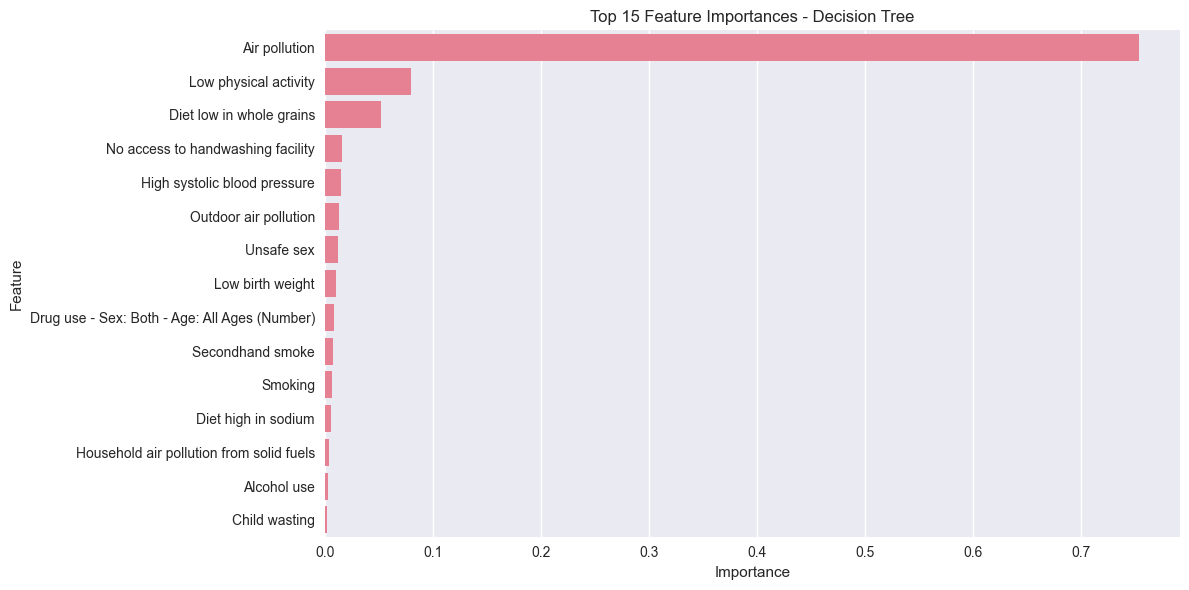

In [114]:
# Feature importance for Decision Tree
feature_importance_dt = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=feature_importance_dt.head(15), x='Importance', y='Feature')
plt.title('Top 15 Feature Importances - Decision Tree')
plt.tight_layout()
plt.show()

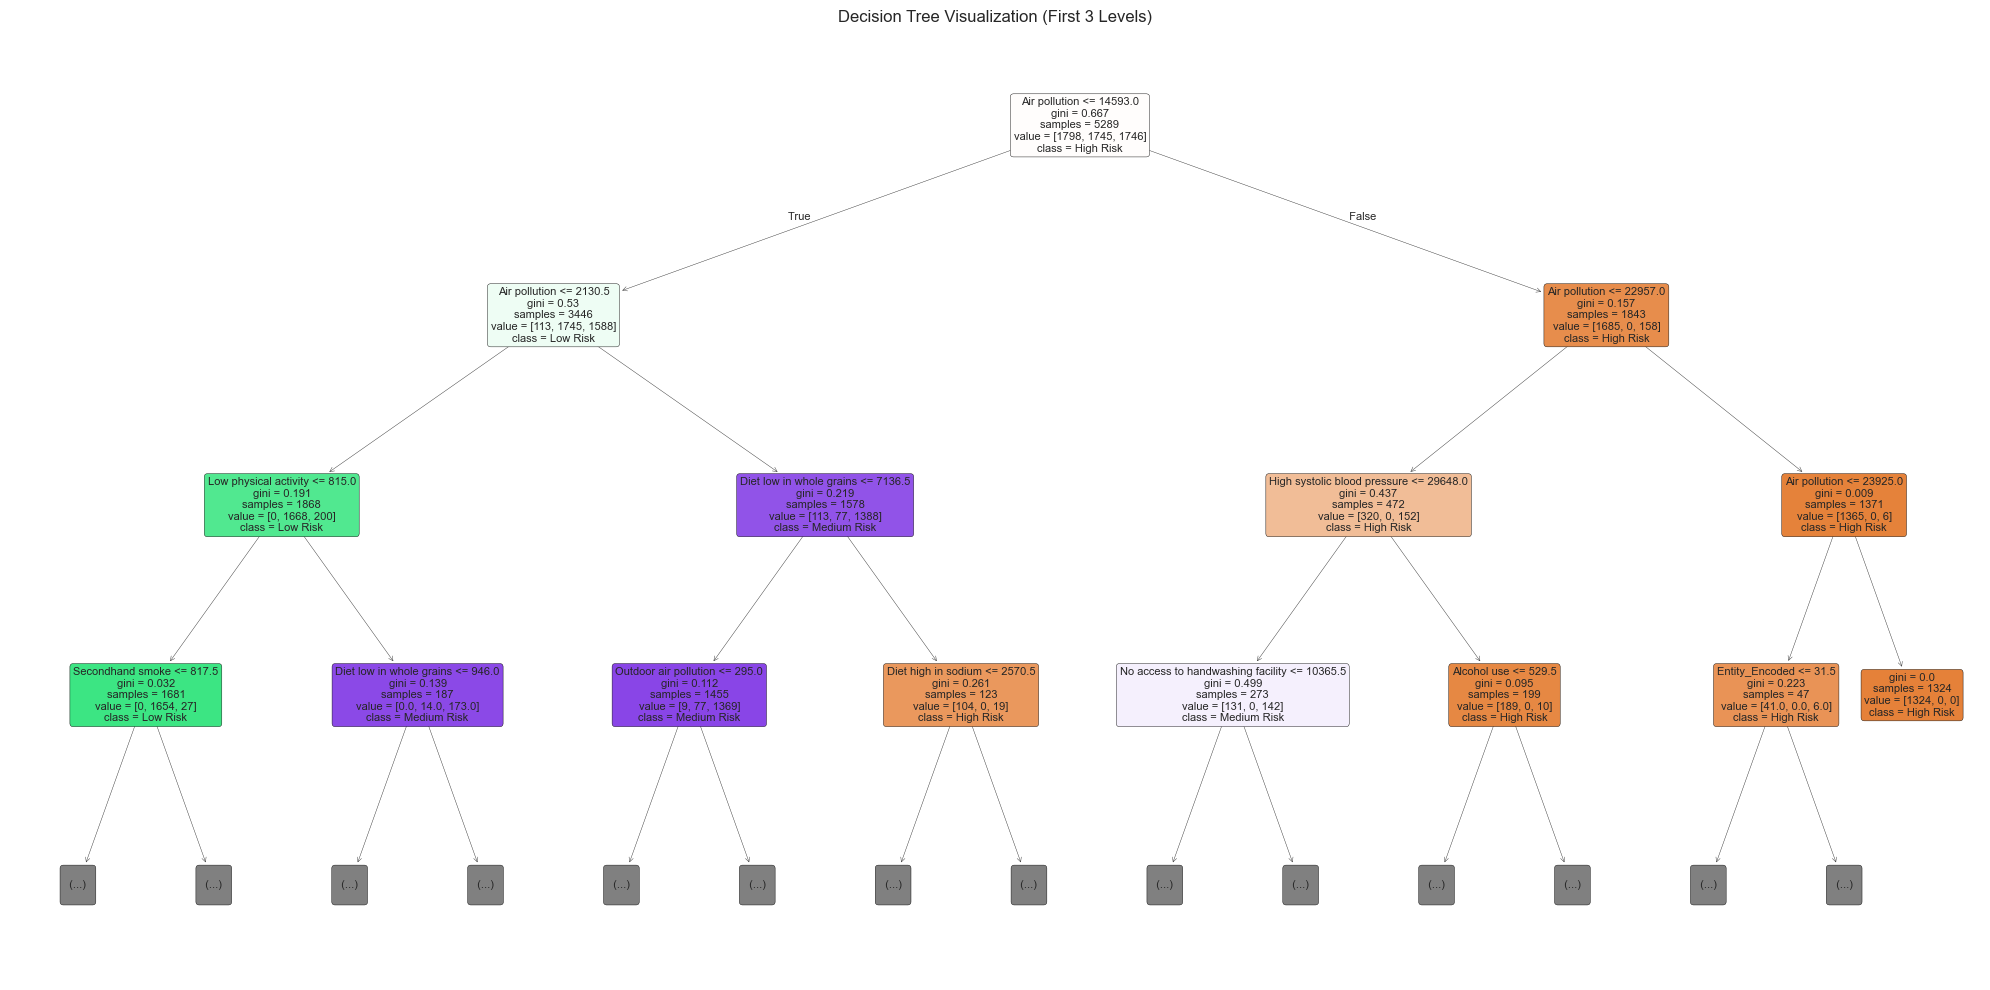

In [115]:
# Visualize Decision Tree (simplified view)
plt.figure(figsize=(20, 10))
plot_tree(dt_model, max_depth=3, feature_names=feature_cols,
          class_names=le_target.classes_, filled=True, rounded=True,
          fontsize=8)
plt.title('Decision Tree Visualization (First 3 Levels)')
plt.tight_layout()
plt.show()

### 5.5 Ensemble Modelling

In [116]:
# Random Forest
print("="*50)
print("RANDOM FOREST")
print("="*50)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=15)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)

# Metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_pred_proba_rf, multi_class='ovr')

print(f"Accuracy: {rf_accuracy:.4f}")
print(f"ROC AUC (One-vs-Rest): {rf_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=le_target.classes_))

RANDOM FOREST
Accuracy: 0.9902
ROC AUC (One-vs-Rest): 0.9997

Classification Report:
              precision    recall  f1-score   support

   High Risk       0.99      1.00      0.99       450
    Low Risk       1.00      0.99      0.99       437
 Medium Risk       0.99      0.98      0.99       436

    accuracy                           0.99      1323
   macro avg       0.99      0.99      0.99      1323
weighted avg       0.99      0.99      0.99      1323



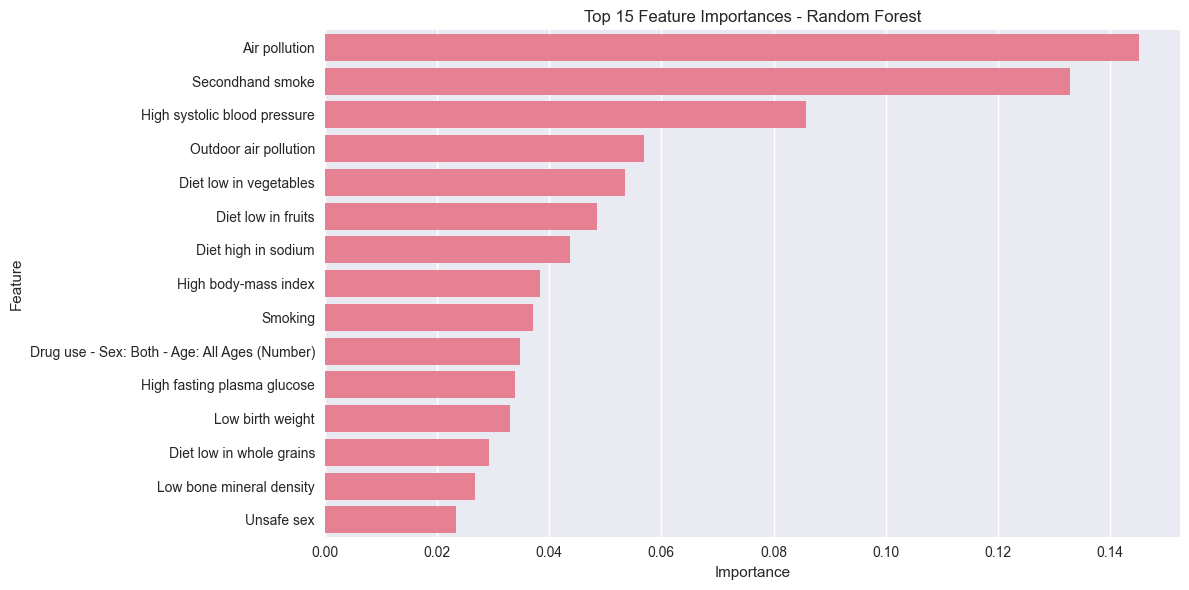

In [117]:
# Feature importance for Random Forest
feature_importance_rf = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=feature_importance_rf.head(15), x='Importance', y='Feature')
plt.title('Top 15 Feature Importances - Random Forest')
plt.tight_layout()
plt.show()

## 6. Model Comparison

Model Comparison:
              Model  Accuracy  ROC AUC
      Random Forest  0.990174 0.999665
      Decision Tree  0.986395 0.990175
     Multinomial LR  0.902494 0.992438
                SVM  0.709751 0.900027
Logistic Regression  0.670446 0.541639


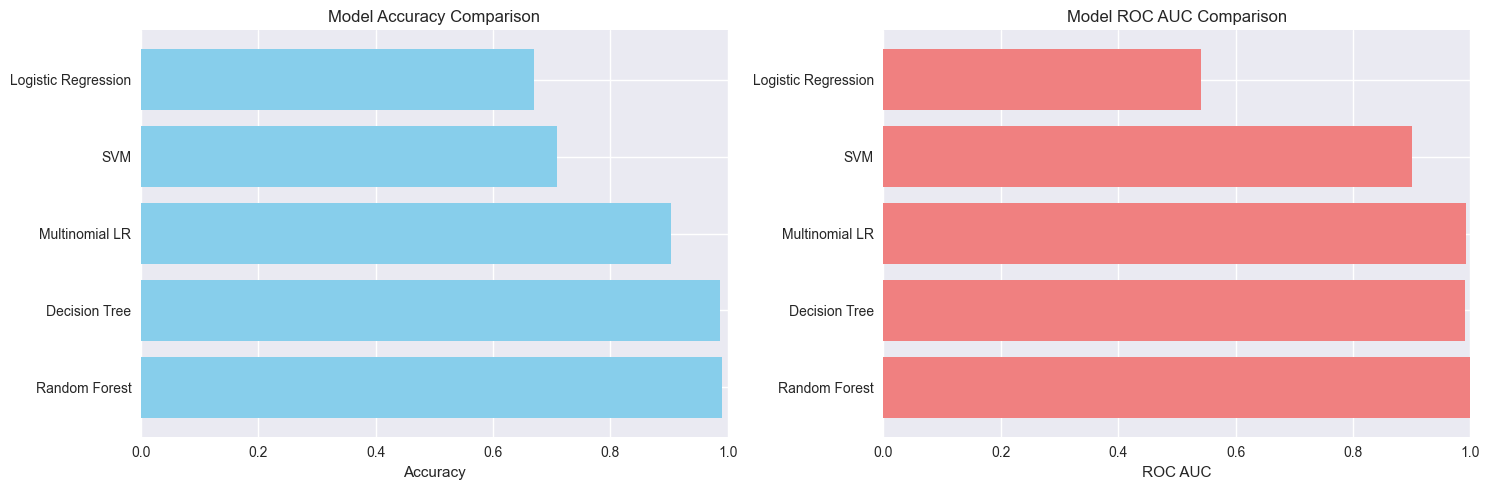

In [118]:
# Compile results
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Multinomial LR', 'SVM', 'Decision Tree',
              'Random Forest'],
    'Accuracy': [lr_accuracy, mlr_accuracy, svm_accuracy, dt_accuracy,
                rf_accuracy],
    'ROC AUC': [lr_auc, mlr_auc, svm_auc, dt_auc,
               rf_auc]
})

results = results.sort_values('Accuracy', ascending=False)
print("Model Comparison:")
print(results.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy comparison
axes[0].barh(results['Model'], results['Accuracy'], color='skyblue')
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_xlim([0, 1])

# ROC AUC comparison
axes[1].barh(results['Model'], results['ROC AUC'], color='lightcoral')
axes[1].set_xlabel('ROC AUC')
axes[1].set_title('Model ROC AUC Comparison')
axes[1].set_xlim([0, 1])

plt.tight_layout()
plt.show()

In [119]:
# Cross-validation comparison
print("="*50)
print("CROSS-VALIDATION RESULTS (5-Fold)")
print("="*50)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Multinomial LR': LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

cv_results = {}
for name, model in models.items():
    if name in ['Logistic Regression', 'Multinomial LR', 'SVM']:
        scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    else:
        scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cv_results[name] = {
        'Mean': scores.mean(),
        'Std': scores.std(),
        'Scores': scores
    }
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")

CROSS-VALIDATION RESULTS (5-Fold)
Logistic Regression: 0.8875 (+/- 0.0107)
Multinomial LR: 0.8875 (+/- 0.0107)
SVM: 0.6629 (+/- 0.0145)
Decision Tree: 0.9805 (+/- 0.0041)
Random Forest: 0.9885 (+/- 0.0025)


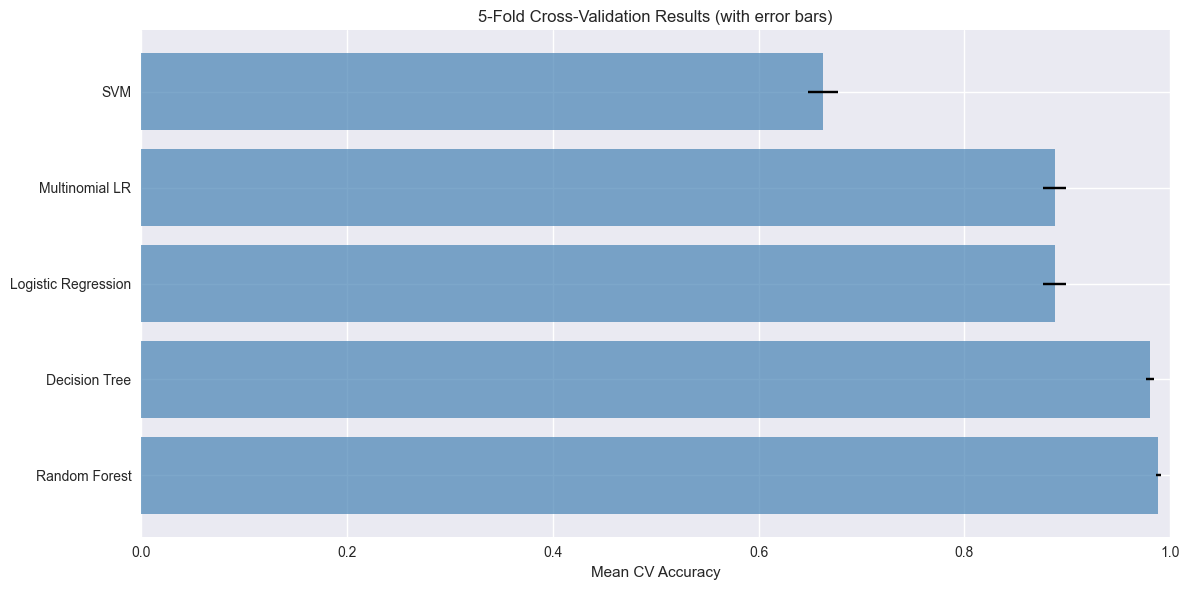

In [120]:
# Plot cross-validation results
cv_df = pd.DataFrame({
    'Model': list(cv_results.keys()),
    'Mean CV Accuracy': [v['Mean'] for v in cv_results.values()],
    'Std Dev': [v['Std'] for v in cv_results.values()]
}).sort_values('Mean CV Accuracy', ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.barh(cv_df['Model'], cv_df['Mean CV Accuracy'], xerr=cv_df['Std Dev'],
               color='steelblue', alpha=0.7, capsize=5)
plt.xlabel('Mean CV Accuracy')
plt.title('5-Fold Cross-Validation Results (with error bars)')
plt.xlim([0, 1])
plt.tight_layout()
plt.show()

## 7. ROC Curves Comparison

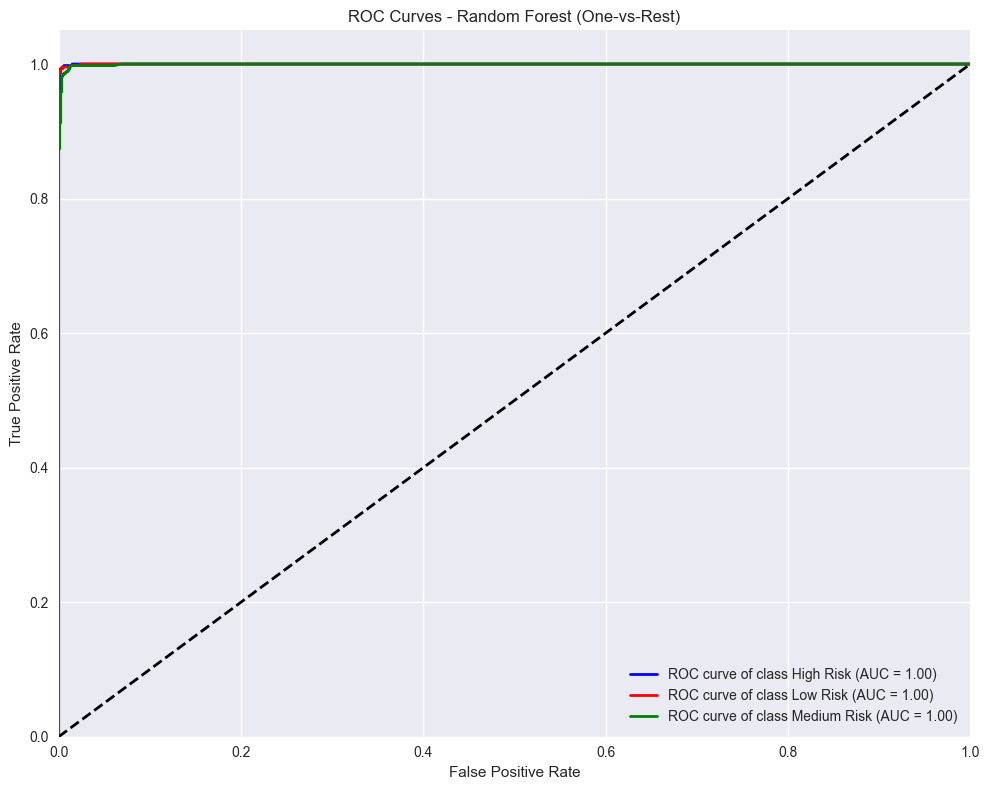

In [121]:
# ROC Curves for each class (using the best model - Random Forest)
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

# Binarize the output
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# Learn to predict each class
classifier = OneVsRestClassifier(RandomForestClassifier(n_estimators=100, random_state=42))
y_score = classifier.fit(X_train, y_train).predict_proba(X_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = roc_auc_score(y_test_bin[:, i], y_score[:, i])

# Plot ROC curves
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of class {le_target.classes_[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Random Forest (One-vs-Rest)')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 8. Prediction Function

In [122]:
def predict_death_risk(entity, year, risk_factors_dict, model=rf_model):
    """
    Predict death risk category for a given entity and year.
    
    Parameters:
    -----------
    entity : str
        Country or region name
    year : int
        Year of prediction
    risk_factors_dict : dict
        Dictionary of risk factor values
    model : sklearn classifier
        Trained model to use for prediction (default: Random Forest)
    
    Returns:
    --------
    dict
        Dictionary containing predicted category and probabilities
    """
    # Create input dataframe
    input_data = {col: 0 for col in feature_cols}
    input_data['Year'] = year
    
    # Handle entity encoding
    if entity in le_entity.classes_:
        input_data['Entity_Encoded'] = le_entity.transform([entity])[0]
    else:
        input_data['Entity_Encoded'] = -1  # Unknown entity
    
    # Handle code encoding
    if entity in le_code.classes_:
        input_data['Code_Encoded'] = le_code.transform([entity])[0]
    else:
        input_data['Code_Encoded'] = -1
    
    # Add risk factors
    for factor, value in risk_factors_dict.items():
        if factor in input_data:
            input_data[factor] = value
    
    # Create dataframe and predict
    input_df = pd.DataFrame([input_data])
    prediction = model.predict(input_df[feature_cols])[0]
    probabilities = model.predict_proba(input_df[feature_cols])[0]
    
    return {
        'Predicted Category': le_target.inverse_transform([prediction])[0],
        'Probabilities': {
            le_target.classes_[i]: prob for i, prob in enumerate(probabilities)
        }
    }

# Example usage
print("Example Prediction Function:")
print("Use predict_death_risk(entity, year, risk_factors_dict) to make predictions")

Example Prediction Function:
Use predict_death_risk(entity, year, risk_factors_dict) to make predictions


## 9. Summary and Conclusions

In [123]:
print("="*60)
print("DEATH RISK PREDICTION - MODEL COMPARISON SUMMARY")
print("="*60)
print()
print("Models Evaluated:")
print("1. Logistic Regression - Binary classification (High Risk vs Others)")
print("2. Multinomial Logistic Regression - Multi-class classification")
print("3. Support Vector Machine (SVM) - Non-linear classification")
print("4. Decision Tree - Interpretable tree-based model")
print("5. Random Forest - Ensemble of decision trees")
print()
print("Key Findings:")
print("-" * 60)
print(f"Best Model by Accuracy: {results.iloc[0]['Model']}")
print(f"Best Accuracy: {results.iloc[0]['Accuracy']:.4f}")
print(f"Best ROC AUC: {results.iloc[0]['ROC AUC']:.4f}")
print()
print("Top Risk Factors (by importance in Random Forest):")
for idx, row in feature_importance_rf.head(10).iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.4f}")
print()
print("Recommendations:")
print("-" * 60)
print("1. Use Random Forest for best accuracy")
print("2. Use Decision Tree for interpretability and feature importance")
print("3. Consider SVM for smaller datasets with clear margins")
print("4. Logistic Regression provides good baseline performance")
print("5. Ensemble methods generally outperform single models")

DEATH RISK PREDICTION - MODEL COMPARISON SUMMARY

Models Evaluated:
1. Logistic Regression - Binary classification (High Risk vs Others)
2. Multinomial Logistic Regression - Multi-class classification
3. Support Vector Machine (SVM) - Non-linear classification
4. Decision Tree - Interpretable tree-based model
5. Random Forest - Ensemble of decision trees

Key Findings:
------------------------------------------------------------
Best Model by Accuracy: Random Forest
Best Accuracy: 0.9902
Best ROC AUC: 0.9997

Top Risk Factors (by importance in Random Forest):
  Air pollution: 0.1452
  Secondhand smoke: 0.1329
  High systolic blood pressure: 0.0858
  Outdoor air pollution: 0.0570
  Diet low in vegetables: 0.0535
  Diet low in fruits: 0.0486
  Diet high in sodium: 0.0438
  High body-mass index: 0.0383
  Smoking: 0.0371
  Drug use - Sex: Both - Age: All Ages (Number): 0.0348

Recommendations:
------------------------------------------------------------
1. Use Random Forest for best accura

## 10. Save Models (Optional)

In [124]:
# Uncomment to save models
# import joblib
#
# joblib.dump(rf_model, 'random_forest_model.pkl')
# joblib.dump(dt_model, 'decision_tree_model.pkl')
# joblib.dump(scaler, 'scaler.pkl')
# joblib.dump(le_target, 'label_encoder.pkl')
#
# print("Models saved successfully!")